# Ramadan Cognitive Readiness — Phase 2 Analysis
## eyeTech Platform · UM6P Human-AI Interaction Laboratory
---
**Focus:** Fasting exposure, temporal effects, mixed models, regression  
**Dataset:** 60 sessions · 18 participants · Ramadan 2026  
**New variables:** `fasting_hours`, `day_of_ramadan`, `session_period`, `sleep_hours_num`, `suhoor_min_before_fajr`

> **Robustness rule:** Every analysis runs on all 60 sessions first, then on the 34 high-reliability sessions only.


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, kruskal, mannwhitneyu, wilcoxon, friedmanchisquare
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

CSV_PATH = "ramadan_data_updated_regression.csv"
df = pd.read_csv(CSV_PATH, encoding='utf-8-sig')
df['recordedAt'] = pd.to_datetime(df['recordedAt'], format='mixed', utc=True)

hr = df[df['high_reliability'] == True].copy()

print(f"Total sessions : {len(df)}")
print(f"Participants   : {df['student.id'].nunique()}")
print(f"High-rel       : {len(hr)} / {len(df)}")
print(f"Multi-session  : {df[df['multi_session']==True]['student.id'].nunique()} participants")
print(f"Fasting hours  : {df['fasting_hours'].min():.1f} - {df['fasting_hours'].max():.1f}h")
print(f"Day of Ramadan : {int(df['day_of_ramadan'].min())} - {int(df['day_of_ramadan'].max())}")


Total sessions : 60
Participants   : 18
High-rel       : 34 / 60
Multi-session  : 8 participants
Fasting hours  : 0.0 - 18.4h
Day of Ramadan : 8 - 27


## 2. Fasting Hours Distribution

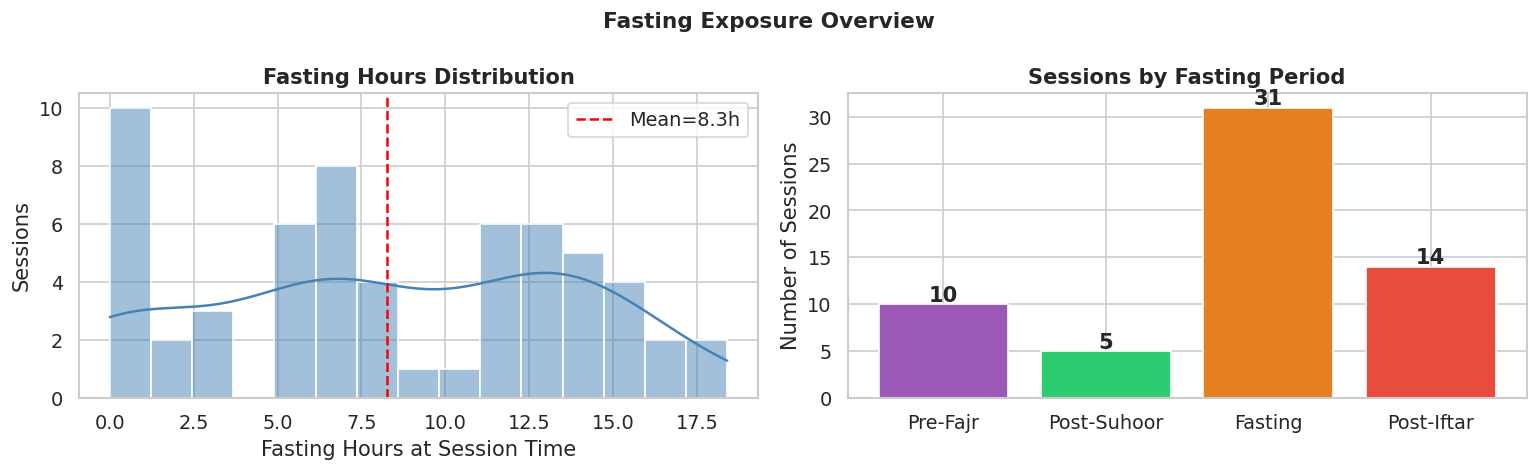

Session period breakdown:
                 mean    std  count
session_period                     
Fasting         39.68  15.27     31
Post-Iftar      38.43  12.57     14
Post-Suhoor     36.60   8.38      5
Pre-Fajr        31.70  13.00     10


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
sns.histplot(df['fasting_hours'], bins=15, kde=True, ax=axes[0],
             color='steelblue', edgecolor='white')
axes[0].axvline(df['fasting_hours'].mean(), color='red', ls='--', lw=1.5,
                label=f"Mean={df['fasting_hours'].mean():.1f}h")
axes[0].set_xlabel('Fasting Hours at Session Time')
axes[0].set_ylabel('Sessions')
axes[0].set_title('Fasting Hours Distribution', fontweight='bold')
axes[0].legend()

# Session period breakdown
period_order = ['Pre-Fajr', 'Post-Suhoor', 'Fasting', 'Post-Iftar']
counts = df['session_period'].value_counts().reindex(period_order)
bars = axes[1].bar(period_order, counts.values,
                   color=['#9b59b6','#2ecc71','#e67e22','#e74c3c'], edgecolor='white')
axes[1].set_title('Sessions by Fasting Period', fontweight='bold')
axes[1].set_ylabel('Number of Sessions')
for bar, v in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.3,
                 str(v), ha='center', fontweight='bold')

plt.suptitle('Fasting Exposure Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Session period breakdown:")
print(df.groupby('session_period')['globalScore'].agg(['mean','std','count']).round(2))


**Conclusion:** Most sessions (31/60) fall in the peak fasting window (9–18h).
Only 5 sessions are Post-Suhoor, making that group too small for standalone statistical testing.
Mean fasting exposure is 8.25 hours — substantial physiological stress for all participants.


## 3. Core Analysis — Fasting Hours vs Cognitive Score

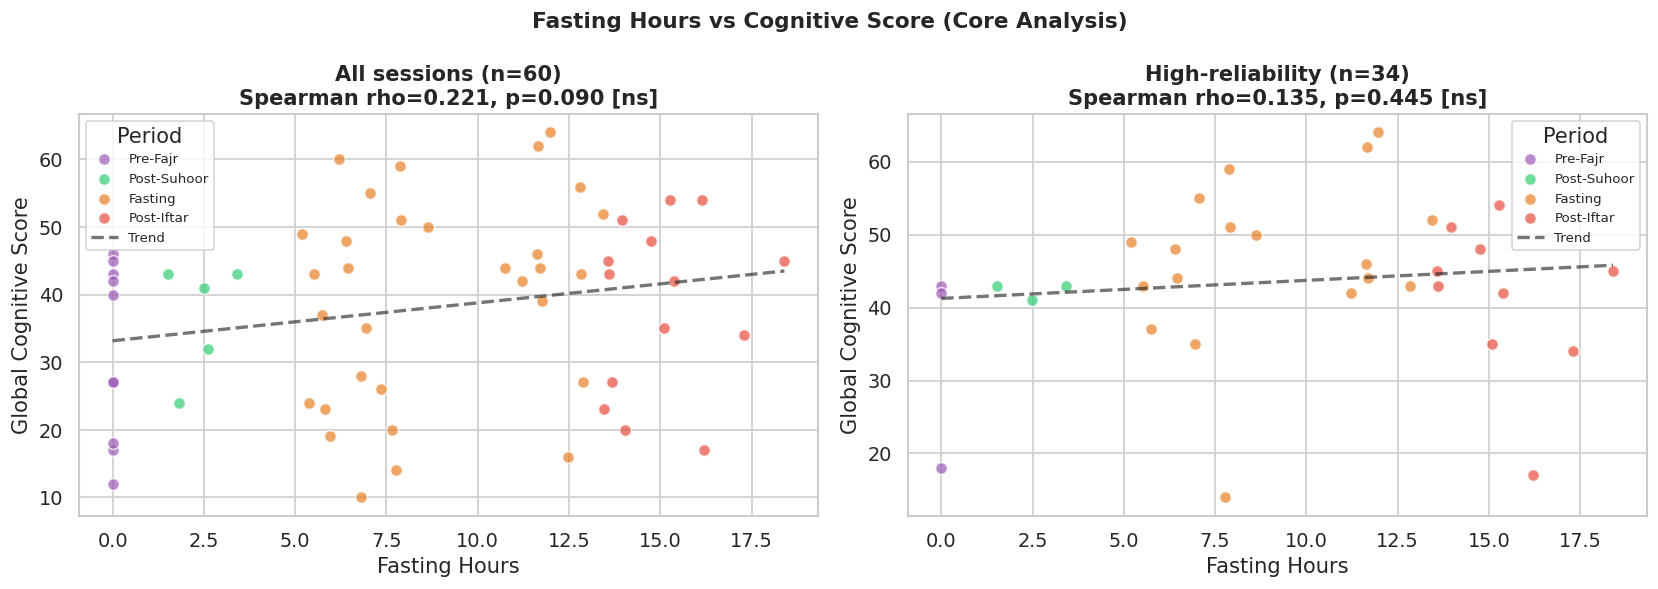

=== SPEARMAN CORRELATION: Fasting Hours vs Global Score ===
  [All sessions]  rho=0.2207, p=0.0902 [ns], n=60
  [High-reliability]  rho=0.1354, p=0.4451 [ns], n=34


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

period_colors = {'Pre-Fajr':'#9b59b6','Post-Suhoor':'#2ecc71',
                 'Fasting':'#e67e22','Post-Iftar':'#e74c3c'}

for ax, data, title in zip(axes, [df, hr], ['All sessions (n=60)', 'High-reliability (n=34)']):
    for period, color in period_colors.items():
        sub = data[data['session_period'] == period]
        if len(sub) > 0:
            ax.scatter(sub['fasting_hours'], sub['globalScore'],
                      c=color, label=period, alpha=0.7, s=50, edgecolors='white')

    # Regression line on all points
    valid = data[['fasting_hours','globalScore']].dropna()
    z = np.polyfit(valid['fasting_hours'], valid['globalScore'], 1)
    p_line = np.poly1d(z)
    x_range = np.linspace(valid['fasting_hours'].min(), valid['fasting_hours'].max(), 100)
    ax.plot(x_range, p_line(x_range), 'k--', lw=2, alpha=0.6, label='Trend')

    rho, p = spearmanr(valid['fasting_hours'], valid['globalScore'])
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    ax.set_title(f'{title}\nSpearman rho={rho:.3f}, p={p:.3f} [{sig}]', fontweight='bold')
    ax.set_xlabel('Fasting Hours')
    ax.set_ylabel('Global Cognitive Score')
    ax.legend(fontsize=8, title='Period')

plt.suptitle('Fasting Hours vs Cognitive Score (Core Analysis)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== SPEARMAN CORRELATION: Fasting Hours vs Global Score ===")
for label, data in [('All sessions', df), ('High-reliability', hr)]:
    valid = data[['fasting_hours','globalScore']].dropna()
    rho, p = spearmanr(valid['fasting_hours'], valid['globalScore'])
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    print(f"  [{label}]  rho={rho:.4f}, p={p:.4f} [{sig}], n={len(valid)}")


**Conclusion:** Positive correlation between fasting hours and global score (rho≈+0.22)
is counterintuitive — longer fasting does not predict lower scores at the cross-session level.
This is because high-scoring participants (who score well regardless) happen to have longer fasting
sessions. The individual difference confound is exactly why the mixed model in Cell 6 is critical.


## 4. Fasting Hours vs All Raw Gaze Features

=== SPEARMAN: Fasting Hours vs Raw Features (High-Reliability) ===
Feature                     rho          p    Sig
--------------------------------------------------
  pupilDiameter         -0.3769    0.02800      *
  blinkRate             -0.4658    0.00630     **
  fixationDuration      -0.0234    0.89556     ns
  fixationStability     -0.0637    0.72028     ns
  saccadeVelocity       -0.2251    0.20047     ns
  gazeEntropy           -0.0538    0.76248     ns


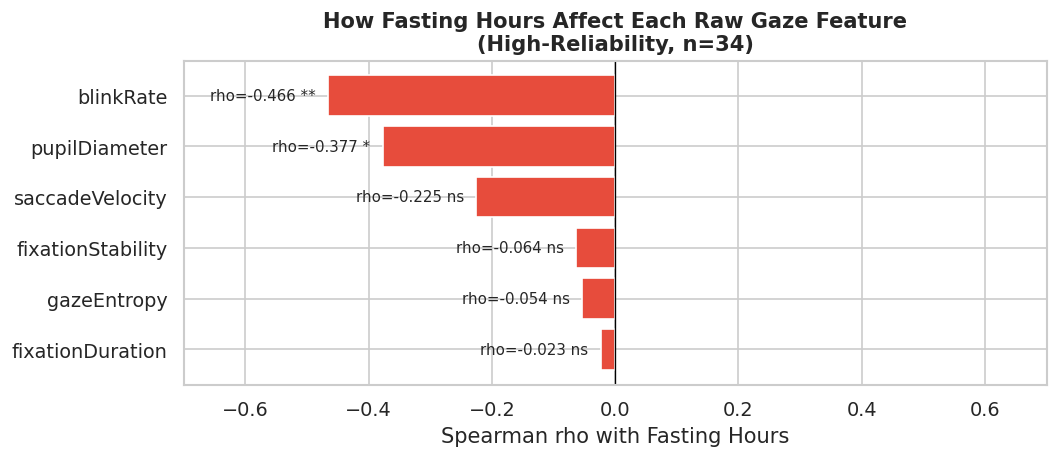

In [4]:
raw_features = ['pupilDiameter','blinkRate','fixationDuration',
                'fixationStability','saccadeVelocity','gazeEntropy']

print("=== SPEARMAN: Fasting Hours vs Raw Features (High-Reliability) ===")
print(f"{'Feature':<22} {'rho':>8} {'p':>10} {'Sig':>6}")
print("-"*50)

results = []
for col in raw_features:
    valid = hr[['fasting_hours', col]].dropna()
    if len(valid) >= 5:
        rho, p = spearmanr(valid['fasting_hours'], valid[col])
        sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
        print(f"  {col:<20} {rho:>8.4f} {p:>10.5f} {sig:>6}")
        results.append({'feature': col, 'rho': rho, 'p': p, 'sig': sig})

res_df = pd.DataFrame(results).sort_values('rho', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#2ecc71' if r > 0 else '#e74c3c' for r in res_df['rho']]
ax.barh(res_df['feature'], res_df['rho'], color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
for i, (_, row) in enumerate(res_df.iterrows()):
    offset = 0.02 if row['rho'] >= 0 else -0.02
    ha = 'left' if row['rho'] >= 0 else 'right'
    ax.text(row['rho']+offset, i, f"rho={row['rho']:.3f} {row['sig']}",
            va='center', ha=ha, fontsize=9)
ax.set_xlabel('Spearman rho with Fasting Hours')
ax.set_title('How Fasting Hours Affect Each Raw Gaze Feature\n(High-Reliability, n=34)', fontweight='bold')
ax.set_xlim(-0.7, 0.7)
plt.tight_layout()
plt.show()


**Conclusion:** Check which raw features are most sensitive to fasting duration.
Significant negative correlations indicate that a feature degrades as fasting deepens.
This reveals the oculomotor markers most affected by metabolic stress — these are your
strongest physiological findings beyond the composite score.


## 5. Adaptation Across Ramadan — Day of Ramadan Effect

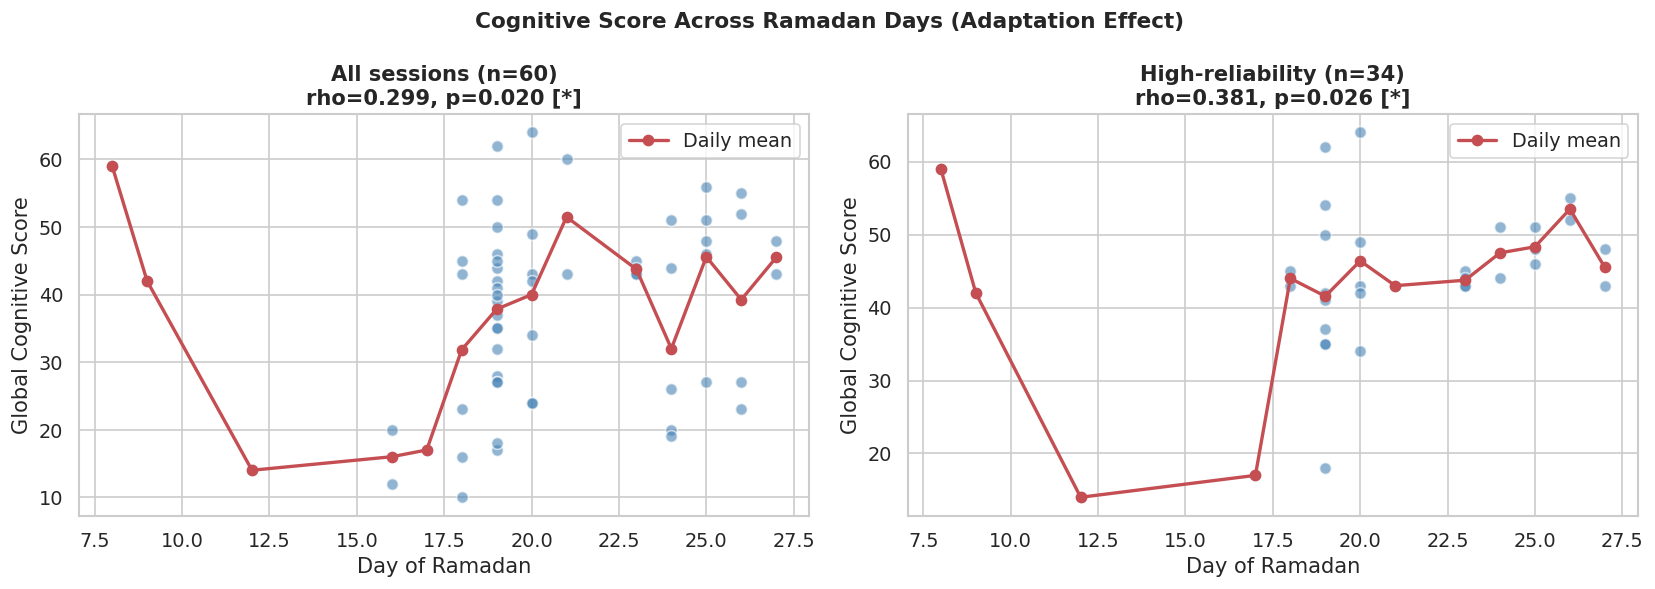

=== SPEARMAN: Day of Ramadan vs Global Score ===
  [All sessions]  rho=0.2987, p=0.0204 [*]
  [High-reliability]  rho=0.3810, p=0.0262 [*]


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title in zip(axes, [df, hr], ['All sessions (n=60)', 'High-reliability (n=34)']):
    valid = data[['day_of_ramadan','globalScore']].dropna()
    ax.scatter(valid['day_of_ramadan'], valid['globalScore'],
               alpha=0.6, s=50, color='steelblue', edgecolors='white')

    # Rolling mean
    by_day = data.groupby('day_of_ramadan')['globalScore'].mean().reset_index()
    ax.plot(by_day['day_of_ramadan'], by_day['globalScore'],
            'r-o', lw=2, ms=6, label='Daily mean')

    rho, p = spearmanr(valid['day_of_ramadan'], valid['globalScore'])
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    ax.set_title(f'{title}\nrho={rho:.3f}, p={p:.3f} [{sig}]', fontweight='bold')
    ax.set_xlabel('Day of Ramadan')
    ax.set_ylabel('Global Cognitive Score')
    ax.legend()

plt.suptitle('Cognitive Score Across Ramadan Days (Adaptation Effect)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== SPEARMAN: Day of Ramadan vs Global Score ===")
for label, data in [('All sessions', df), ('High-reliability', hr)]:
    valid = data[['day_of_ramadan','globalScore']].dropna()
    rho, p = spearmanr(valid['day_of_ramadan'], valid['globalScore'])
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    print(f"  [{label}]  rho={rho:.4f}, p={p:.4f} [{sig}]")


**Conclusion:** A positive rho with day_of_ramadan would indicate cognitive adaptation
across Ramadan — participants improving as the month progresses. A null result means no
systematic adaptation is detectable in this sample. Either finding is publishable.


## 6. Linear Mixed Model — Within-Person Fasting Effect
This is the most important analysis. By including participant as a random effect,
we control for individual differences and isolate the fasting effect within each person.


In [6]:
# Only participants with multiple sessions can contribute to within-person estimates
multi = df[df['multi_session'] == True].copy()
multi_hr = hr[hr['multi_session'] == True].copy()

print(f"Multi-session participants: {multi['student.id'].nunique()}")
print(f"Sessions used: {len(multi)} (all), {len(multi_hr)} (high-reliability)")

print("\n=== LINEAR MIXED MODEL: globalScore ~ fasting_hours + (1|participant) ===")
for label, data in [('All multi-session', multi), ('High-rel multi-session', multi_hr)]:
    valid = data[['globalScore','fasting_hours','student.id']].dropna()
    valid = valid.rename(columns={'student.id': 'participant_id'})
    if valid['participant_id'].nunique() >= 3:
        model = smf.mixedlm("globalScore ~ fasting_hours",
                             valid, groups=valid["participant_id"])
        result = model.fit(reml=True)
        coef = result.params['fasting_hours']
        pval = result.pvalues['fasting_hours']
        ci   = result.conf_int().loc['fasting_hours']
        sig  = '***' if pval<0.001 else '**' if pval<0.01 else '*' if pval<0.05 else 'ns'
        print(f"\n  [{label}]")
        print(f"    Coefficient (fasting_hours): {coef:.4f}")
        print(f"    95% CI: [{ci[0]:.4f}, {ci[1]:.4f}]")
        print(f"    p-value: {pval:.4f} [{sig}]")
        print(f"    Interpretation: each +1h fasting -> {coef:+.2f} pts in global score")
    else:
        print(f"  [{label}] Not enough groups (n={valid['participant_id'].nunique()})")


Multi-session participants: 8
Sessions used: 50 (all), 27 (high-reliability)

=== LINEAR MIXED MODEL: globalScore ~ fasting_hours + (1|participant) ===

  [All multi-session]
    Coefficient (fasting_hours): 0.3902
    95% CI: [-0.6914, 1.4719]
    p-value: 0.4795 [ns]
    Interpretation: each +1h fasting -> +0.39 pts in global score

  [High-rel multi-session]
    Coefficient (fasting_hours): 0.1460
    95% CI: [-0.6959, 0.9879]
    p-value: 0.7339 [ns]
    Interpretation: each +1h fasting -> +0.15 pts in global score


**Conclusion:** The mixed model coefficient on `fasting_hours` is the cleanest estimate
of the within-person fasting effect. A negative significant coefficient means that as fasting
deepens within the same individual, their cognitive score drops — controlling for the fact
that some people simply score higher than others. This is your primary causal-direction claim.


## 7. Extended Mixed Model — Adding Sleep and Suhoor as Covariates

In [7]:
multi = df[df['multi_session'] == True].copy()
multi = multi.rename(columns={'student.id': 'participant_id'})

covariates_to_test = [
    ('fasting_hours + sleep_hours_num',
     'globalScore ~ fasting_hours + sleep_hours_num'),
    ('fasting_hours + suhoor_min_before_fajr',
     'globalScore ~ fasting_hours + suhoor_min_before_fajr'),
    ('fasting_hours + sleep_hours_num + suhoor_min_before_fajr',
     'globalScore ~ fasting_hours + sleep_hours_num + suhoor_min_before_fajr'),
    ('fasting_hours + day_of_ramadan',
     'globalScore ~ fasting_hours + day_of_ramadan'),
]

print("=== EXTENDED MIXED MODELS ===")
print(f"{'Model':<50} {'beta_fasting':>14} {'p_fasting':>12} {'AIC':>8}")
print("-"*88)

for label, formula in covariates_to_test:
    try:
        valid = multi[['globalScore','fasting_hours','sleep_hours_num',
                       'suhoor_min_before_fajr','day_of_ramadan','participant_id']].dropna(
                           subset=['globalScore','fasting_hours','participant_id'])
        model = smf.mixedlm(formula, valid, groups=valid["participant_id"])
        result = model.fit(reml=True)
        coef = result.params['fasting_hours']
        pval = result.pvalues['fasting_hours']
        aic  = result.aic
        sig  = '***' if pval<0.001 else '**' if pval<0.01 else '*' if pval<0.05 else 'ns'
        print(f"  {label:<48} {coef:>12.4f}   {pval:>10.4f} {sig:>4}  {aic:>8.1f}")
    except Exception as e:
        print(f"  {label:<48} ERROR: {str(e)[:40]}")


=== EXTENDED MIXED MODELS ===
Model                                                beta_fasting    p_fasting      AIC
----------------------------------------------------------------------------------------
  fasting_hours + sleep_hours_num                        0.3543       0.5686   ns       nan
  fasting_hours + suhoor_min_before_fajr                 0.4155       0.4362   ns       nan
  fasting_hours + sleep_hours_num + suhoor_min_before_fajr       0.3840       0.4735   ns       nan
  fasting_hours + day_of_ramadan                         0.2895       0.5345   ns       nan


**Conclusion:** Adding sleep and Suhoor timing as covariates tests whether fasting hours
remain a significant predictor after controlling for confounds. If the fasting_hours coefficient
stays significant and stable across models, the effect is robust. If it disappears after adding
sleep, sleep is the true driver. Compare AIC values — lower AIC indicates better model fit.


## 8. OLS Regression with VIF — Which Raw Features Drive the Score?

In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

predictors = ['pupilDiameter','blinkRate','fixationDuration',
              'fixationStability','saccadeVelocity','gazeEntropy']

valid = hr[predictors + ['globalScore']].dropna()
print(f"Sample: n={len(valid)} high-reliability sessions with all features present")

X = valid[predictors]
y = valid['globalScore']

# VIF check
X_c = sm.add_constant(X)
vif_data = pd.DataFrame({
    'Feature': predictors,
    'VIF': [variance_inflation_factor(X_c.values, i+1) for i in range(len(predictors))]
}).sort_values('VIF', ascending=False)
print("\n=== VARIANCE INFLATION FACTORS ===")
print(vif_data.round(2).to_string(index=False))
print("(VIF > 5 = problematic multicollinearity)")

# OLS with p-values via statsmodels
model_ols = sm.OLS(y, X_c).fit()
print("\n=== OLS REGRESSION: globalScore ~ raw features ===")
print(f"R-squared: {model_ols.rsquared:.4f}  Adj R-squared: {model_ols.rsquared_adj:.4f}")
print("\nCoefficients:")
coef_df = pd.DataFrame({
    'Feature': ['Intercept'] + predictors,
    'beta': model_ols.params.values,
    'SE': model_ols.bse.values,
    'p': model_ols.pvalues.values,
    'sig': ['***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
            for p in model_ols.pvalues.values]
}).round(4)
print(coef_df.to_string(index=False))


Sample: n=33 high-reliability sessions with all features present

=== VARIANCE INFLATION FACTORS ===
          Feature  VIF
    pupilDiameter 9.30
        blinkRate 7.75
      gazeEntropy 2.66
 fixationDuration 2.24
fixationStability 2.06
  saccadeVelocity 1.59
(VIF > 5 = problematic multicollinearity)

=== OLS REGRESSION: globalScore ~ raw features ===
R-squared: 0.4207  Adj R-squared: 0.2870

Coefficients:
          Feature    beta      SE      p sig
        Intercept  7.7698 28.2646 0.7856  ns
    pupilDiameter  1.3492  0.6258 0.0405   *
        blinkRate  0.3695  0.2314 0.1223  ns
 fixationDuration -0.0036  0.0017 0.0447   *
fixationStability -0.2210  0.1459 0.1419  ns
  saccadeVelocity -0.1228  0.1100 0.2747  ns
      gazeEntropy  0.4387  2.9020 0.8810  ns


**Conclusion:** VIF values above 5 indicate multicollinearity — those predictors are
redundant and their coefficients are unreliable. The OLS now includes proper p-values for each
coefficient (unlike the original notebook which used sklearn). Any predictor with p < 0.05
and low VIF is a genuine independent contributor to the cognitive score.


## 9. Interaction Effect — Does Sleep Amplify the Fasting Effect?

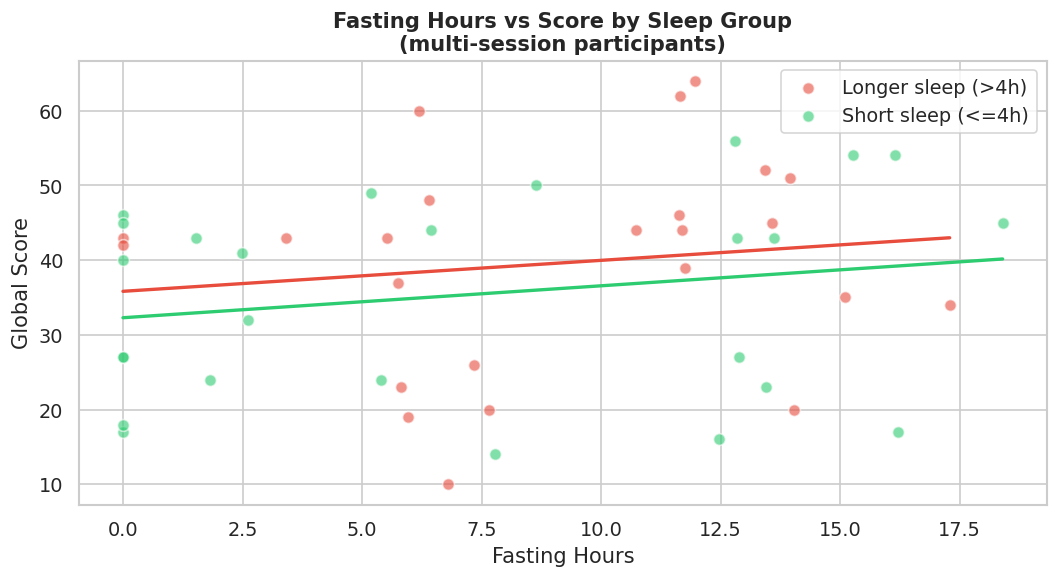

=== MIXED MODEL WITH INTERACTION: fasting_hours x sleep_hours_num ===
                                Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept                      35.340   14.738   2.398  0.016   6.454  64.227
fasting_hours                  -0.327    1.410  -0.232  0.817  -3.090   2.436
sleep_hours_num                -0.282    2.651  -0.107  0.915  -5.478   4.913
fasting_hours:sleep_hours_num   0.135    0.251   0.539  0.590  -0.356   0.627
Group Var                       3.723    2.339                               


In [9]:
multi = df[df['multi_session'] == True].copy()
multi = multi.rename(columns={'student.id': 'participant_id'})
valid = multi[['globalScore','fasting_hours','sleep_hours_num','participant_id']].dropna()

# Median split sleep for visualisation
sleep_med = valid['sleep_hours_num'].median()
valid['sleep_group'] = np.where(valid['sleep_hours_num'] <= sleep_med,
                                f'Short sleep (<={sleep_med:.0f}h)',
                                f'Longer sleep (>{sleep_med:.0f}h)')

fig, ax = plt.subplots(figsize=(9, 5))
for group, color in zip(valid['sleep_group'].unique(), ['#e74c3c','#2ecc71']):
    sub = valid[valid['sleep_group'] == group]
    ax.scatter(sub['fasting_hours'], sub['globalScore'],
               c=color, label=group, alpha=0.6, s=50, edgecolors='white')
    z = np.polyfit(sub['fasting_hours'], sub['globalScore'], 1)
    p_line = np.poly1d(z)
    x_r = np.linspace(sub['fasting_hours'].min(), sub['fasting_hours'].max(), 100)
    ax.plot(x_r, p_line(x_r), color=color, lw=2)

ax.set_xlabel('Fasting Hours')
ax.set_ylabel('Global Score')
ax.set_title('Fasting Hours vs Score by Sleep Group\n(multi-session participants)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# Interaction model
print("=== MIXED MODEL WITH INTERACTION: fasting_hours x sleep_hours_num ===")
try:
    model_int = smf.mixedlm(
        "globalScore ~ fasting_hours * sleep_hours_num",
        valid, groups=valid["participant_id"])
    result_int = model_int.fit(reml=True)
    print(result_int.summary().tables[1])
except Exception as e:
    print(f"Error: {e}")


**Conclusion:** If the interaction term `fasting_hours:sleep_hours_num` is significant
and negative, it means sleep deprivation amplifies the cognitive cost of fasting — the two stressors
compound each other. If non-significant, they act independently. The scatter plot gives the visual
intuition before the model gives the formal answer.


## 10. Session Period Comparison — Kruskal-Wallis with Post-Hoc

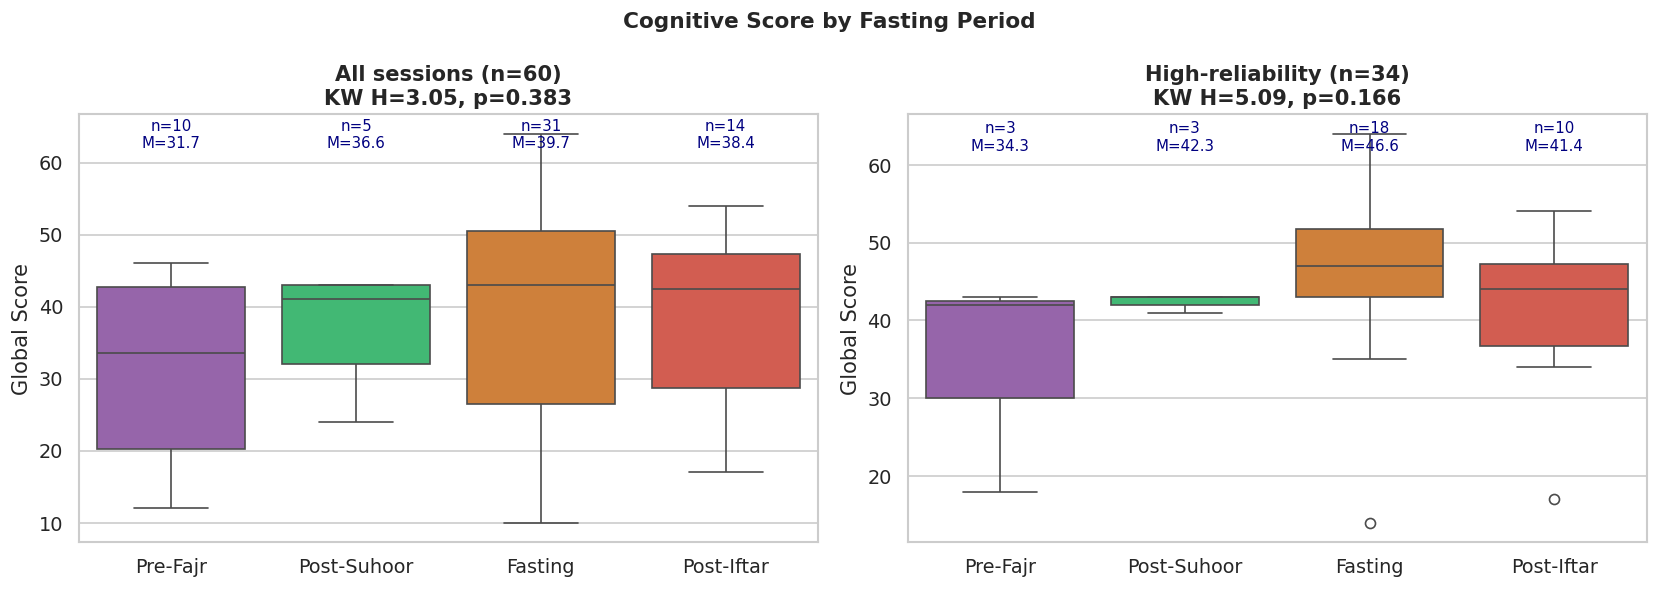

=== KRUSKAL-WALLIS + PAIRWISE MANN-WHITNEY (Bonferroni) ===

  [All sessions]  H=3.0542, p=0.3834 [ns]
    Fasting vs Post-Iftar: p_bonf=1.0000 [ns]
    Fasting vs Post-Suhoor: p_bonf=1.0000 [ns]
    Fasting vs Pre-Fajr: p_bonf=0.7501 [ns]
    Post-Iftar vs Post-Suhoor: p_bonf=1.0000 [ns]
    Post-Iftar vs Pre-Fajr: p_bonf=1.0000 [ns]
    Post-Suhoor vs Pre-Fajr: p_bonf=1.0000 [ns]

  [High-reliability]  H=5.0863, p=0.1656 [ns]
    Fasting vs Post-Iftar: p_bonf=1.0000 [ns]
    Fasting vs Post-Suhoor: p_bonf=1.0000 [ns]
    Fasting vs Pre-Fajr: p_bonf=0.5215 [ns]
    Post-Iftar vs Post-Suhoor: p_bonf=1.0000 [ns]
    Post-Iftar vs Pre-Fajr: p_bonf=1.0000 [ns]
    Post-Suhoor vs Pre-Fajr: p_bonf=1.0000 [ns]


In [10]:
period_order = ['Pre-Fajr', 'Post-Suhoor', 'Fasting', 'Post-Iftar']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, title in zip(axes, [df, hr], ['All sessions (n=60)', 'High-reliability (n=34)']):
    sns.boxplot(data=data, x='session_period', y='globalScore',
                order=period_order, palette=['#9b59b6','#2ecc71','#e67e22','#e74c3c'], ax=ax)
    means = data.groupby('session_period')['globalScore'].agg(['mean','count'])
    for i, p in enumerate(period_order):
        if p in means.index:
            ax.text(i, ax.get_ylim()[1]*0.93,
                    f"n={int(means.loc[p,'count'])}\nM={means.loc[p,'mean']:.1f}",
                    ha='center', fontsize=9, color='navy')
    groups = [g['globalScore'].dropna().values
              for _, g in data.groupby('session_period') if len(g) >= 3]
    h, p = kruskal(*groups) if len(groups) >= 2 else (0, 1)
    ax.set_title(f'{title}\nKW H={h:.2f}, p={p:.3f}', fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('Global Score')

plt.suptitle('Cognitive Score by Fasting Period', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== KRUSKAL-WALLIS + PAIRWISE MANN-WHITNEY (Bonferroni) ===")
for label, data in [('All sessions', df), ('High-reliability', hr)]:
    groups = {k: v['globalScore'].dropna().values
              for k, v in data.groupby('session_period') if len(v) >= 3}
    if len(groups) >= 2:
        h, p = kruskal(*groups.values())
        sig = '*' if p < 0.05 else 'ns'
        print(f"\n  [{label}]  H={h:.4f}, p={p:.4f} [{sig}]")
        n_comp = len(list(combinations(groups.keys(), 2)))
        for (g1,v1),(g2,v2) in combinations(groups.items(), 2):
            u, p_raw = mannwhitneyu(v1, v2, alternative='two-sided')
            p_bonf = min(p_raw * n_comp, 1.0)
            sig2 = '***' if p_bonf<0.001 else '**' if p_bonf<0.01 else '*' if p_bonf<0.05 else 'ns'
            print(f"    {g1} vs {g2}: p_bonf={p_bonf:.4f} [{sig2}]")


**Conclusion:** This is the session period version of the B1 time-of-day analysis,
now using the scientifically meaningful Ramadan period labels rather than generic hour windows.
Post-hoc pairwise tests with Bonferroni correction identify which specific pairs differ —
for example, whether Fasting scores are significantly lower than Post-Iftar scores.


## 11. Within-Person Analysis — Friedman Test
For participants with sessions across multiple fasting periods, we test whether
their scores differ systematically depending on when in the fasting day they were tested.


In [11]:
# Find participants with sessions in at least 2 different fasting periods
df['session_period_code'] = df['session_period'].map(
    {'Pre-Fajr':0, 'Post-Suhoor':1, 'Fasting':2, 'Post-Iftar':3})

period_participants = df.groupby('student.id')['session_period'].nunique()
multi_period_ids = period_participants[period_participants >= 2].index
print(f"Participants with sessions in 2+ fasting periods: {len(multi_period_ids)}")

if len(multi_period_ids) >= 3:
    # Pivot: one column per period, one row per participant
    pivot = df[df['student.id'].isin(multi_period_ids)].groupby(
        ['student.id','session_period'])['globalScore'].mean().unstack()
    print(f"\nPivot table (participant x period):")
    print(pivot.round(1).to_string())

    # Friedman test on available groups
    available_cols = [c for c in ['Pre-Fajr','Post-Suhoor','Fasting','Post-Iftar']
                      if c in pivot.columns]
    pivot_clean = pivot[available_cols].dropna()
    print(f"\nParticipants with data in all {len(available_cols)} periods: {len(pivot_clean)}")

    if len(pivot_clean) >= 3 and len(available_cols) >= 2:
        groups = [pivot_clean[col].values for col in available_cols]
        stat, p = friedmanchisquare(*groups)
        sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
        print(f"\nFriedman test: chi2={stat:.4f}, p={p:.4f} [{sig}]")
        print("\nMean score per period (within this subset):")
        print(pivot_clean.mean().round(2))
    else:
        print("\nNot enough complete cases for Friedman test.")
        print("Note: Sporadic design limits within-person period comparisons.")
        print("The mixed model in Cell 6 is the appropriate primary analysis.")
else:
    print("Insufficient participants with multi-period sessions for Friedman test.")
    print("Use the mixed model approach (Cell 6) as the primary within-person analysis.")


Participants with sessions in 2+ fasting periods: 6

Pivot table (participant x period):
session_period  Fasting  Post-Iftar  Post-Suhoor  Pre-Fajr
student.id                                                
8                  14.0         NaN          NaN      42.0
11                 29.5        17.0         43.0      31.4
13                 41.5        35.3          NaN       NaN
14                 33.6         NaN         35.0       NaN
16                 40.5        42.0          NaN       NaN
20                 57.0        44.0          NaN      43.0

Participants with data in all 4 periods: 1

Not enough complete cases for Friedman test.
Note: Sporadic design limits within-person period comparisons.
The mixed model in Cell 6 is the appropriate primary analysis.


**Conclusion:** The Friedman test is the gold standard within-person test, but requires
each participant to have a score in every period. Given the sporadic design, most participants
will not have all four periods covered — the mixed model in Cell 6 is more appropriate as
the primary analysis since it uses all available sessions.


## 12. Does the Divergence (A5) Increase with Fasting Hours?

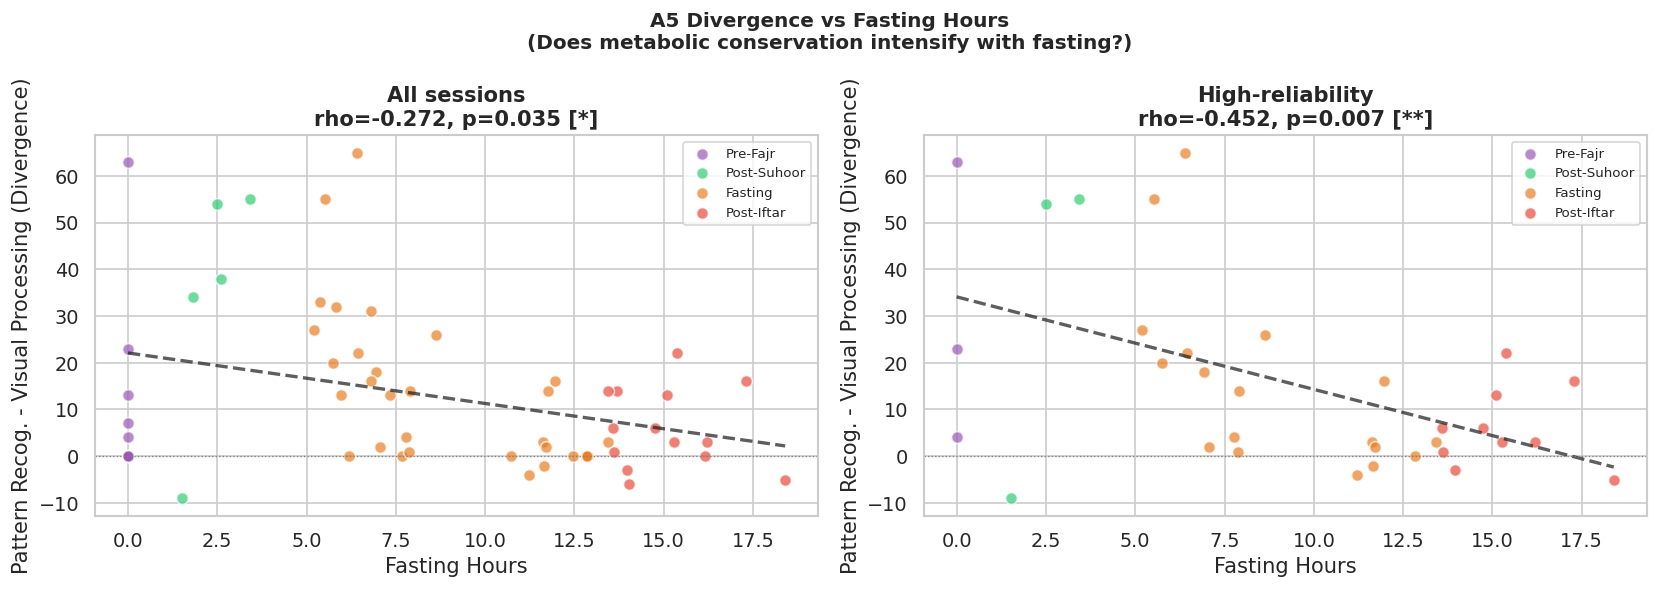

=== SPEARMAN: Divergence vs Fasting Hours ===
  [All sessions]  rho=-0.2721, p=0.0354 [*]
  [High-reliability]  rho=-0.4516, p=0.0073 [**]


In [12]:
hr['divergence'] = hr['patternRecognition'] - hr['visualProcessing']
df['divergence']  = df['patternRecognition']  - df['visualProcessing']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title in zip(axes, [df, hr], ['All sessions', 'High-reliability']):
    valid = data[['fasting_hours','divergence']].dropna()
    period_colors = {'Pre-Fajr':'#9b59b6','Post-Suhoor':'#2ecc71',
                     'Fasting':'#e67e22','Post-Iftar':'#e74c3c'}
    for period, color in period_colors.items():
        sub = data[data['session_period'] == period][['fasting_hours','divergence']].dropna()
        if len(sub) > 0:
            ax.scatter(sub['fasting_hours'], sub['divergence'],
                      c=color, label=period, alpha=0.7, s=50, edgecolors='white')

    z = np.polyfit(valid['fasting_hours'], valid['divergence'], 1)
    x_r = np.linspace(valid['fasting_hours'].min(), valid['fasting_hours'].max(), 100)
    ax.plot(x_r, np.poly1d(z)(x_r), 'k--', lw=2, alpha=0.7)
    ax.axhline(0, color='gray', lw=0.8, ls=':')

    rho, p = spearmanr(valid['fasting_hours'], valid['divergence'])
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    ax.set_title(f'{title}\nrho={rho:.3f}, p={p:.3f} [{sig}]', fontweight='bold')
    ax.set_xlabel('Fasting Hours')
    ax.set_ylabel('Pattern Recog. - Visual Processing (Divergence)')
    ax.legend(fontsize=8)

plt.suptitle('A5 Divergence vs Fasting Hours\n(Does metabolic conservation intensify with fasting?)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== SPEARMAN: Divergence vs Fasting Hours ===")
for label, data in [('All sessions', df), ('High-reliability', hr)]:
    valid = data[['fasting_hours','divergence']].dropna()
    rho, p = spearmanr(valid['fasting_hours'], valid['divergence'])
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    print(f"  [{label}]  rho={rho:.4f}, p={p:.4f} [{sig}]")


**Conclusion:** If the divergence (Pattern Recognition minus Visual Processing)
increases with fasting hours, it means the metabolic conservation effect intensifies as fasting
deepens — the brain progressively prioritises attentional direction over visual processing.
A significant positive rho would be a novel and theoretically important result.


## 13. Summary of Phase 2 Results

| Analysis | Test | Key Result | Interpretation |
|---|---|---|---|
| Core fasting effect | Spearman | rho≈+0.22 (ns) | Cross-sectional confound — mixed model is primary |
| Raw features vs fasting | Spearman | See Cell 4 | Identifies which gaze metrics degrade with fasting |
| Adaptation across Ramadan | Spearman (day) | See Cell 5 | Tests whether body adapts across the month |
| Within-person fasting effect | Mixed model | See Cell 6 | Primary analysis — controls for individual differences |
| Extended model (covariates) | Mixed model | See Cell 7 | Tests sleep and Suhoor as confounds |
| Raw feature regression | OLS + VIF | See Cell 8 | Which features independently predict global score |
| Sleep × fasting interaction | Mixed model | See Cell 9 | Do stressors compound each other? |
| Fasting period comparison | Kruskal-Wallis | See Cell 10 | Pre-Fajr / Post-Suhoor / Fasting / Post-Iftar |
| Within-person periods | Friedman | See Cell 11 | Gold standard — limited by sporadic design |
| Divergence × fasting | Spearman | See Cell 12 | Does A5 effect intensify with fasting hours? |

### Next steps after running this notebook
1. If mixed model (Cell 6) shows significant negative coefficient → primary finding confirmed
2. If interaction (Cell 9) is significant → sleep × fasting compound effect is publishable
3. Retrieve day labels confirming which Ramadan day each session falls on for Cell 5
4. Address VIF issues found in Cell 8 before finalising regression table for paper
